In [5]:
from config import DATA_DIR, CHARTS_DIR
import pandas as pd
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import random
from src.autoencoder import create_autoencoder

## Data loading

In [6]:
print("Loading data to RAM...")
csv_file_path = DATA_DIR / 'processed_data.csv'

df = pd.read_csv(csv_file_path)
print("Data loaded successfully!")


Loading data to RAM...
Data loaded successfully!


## MSE chart

--- PROFILING FOR BOTTLENECK: 3 ---
[1/17] Processing CAN ID: 2 (Bottleneck: 3)... Finished! (MSE: 0.0101)
[2/17] Processing CAN ID: 160 (Bottleneck: 3)... Finished! (MSE: 0.0055)
[3/17] Processing CAN ID: 161 (Bottleneck: 3)... Finished! (MSE: 0.0112)
[4/17] Processing CAN ID: 304 (Bottleneck: 3)... Finished! (MSE: 0.0165)
[5/17] Processing CAN ID: 320 (Bottleneck: 3)... Finished! (MSE: 0.0159)
[6/17] Processing CAN ID: 339 (Bottleneck: 3)... Finished! (MSE: 0.0003)
[7/17] Processing CAN ID: 399 (Bottleneck: 3)... Finished! (MSE: 0.0155)
[8/17] Processing CAN ID: 497 (Bottleneck: 3)... Finished! (MSE: 0.0138)
[9/17] Processing CAN ID: 544 (Bottleneck: 3)... Finished! (MSE: 0.0125)
[10/17] Processing CAN ID: 608 (Bottleneck: 3)... Finished! (MSE: 0.0279)
[11/17] Processing CAN ID: 672 (Bottleneck: 3)... Finished! (MSE: 0.0089)
[12/17] Processing CAN ID: 688 (Bottleneck: 3)... Finished! (MSE: 0.0049)
[13/17] Processing CAN ID: 790 (Bottleneck: 3)... Finished! (MSE: 0.0135)
[14/17] Proce

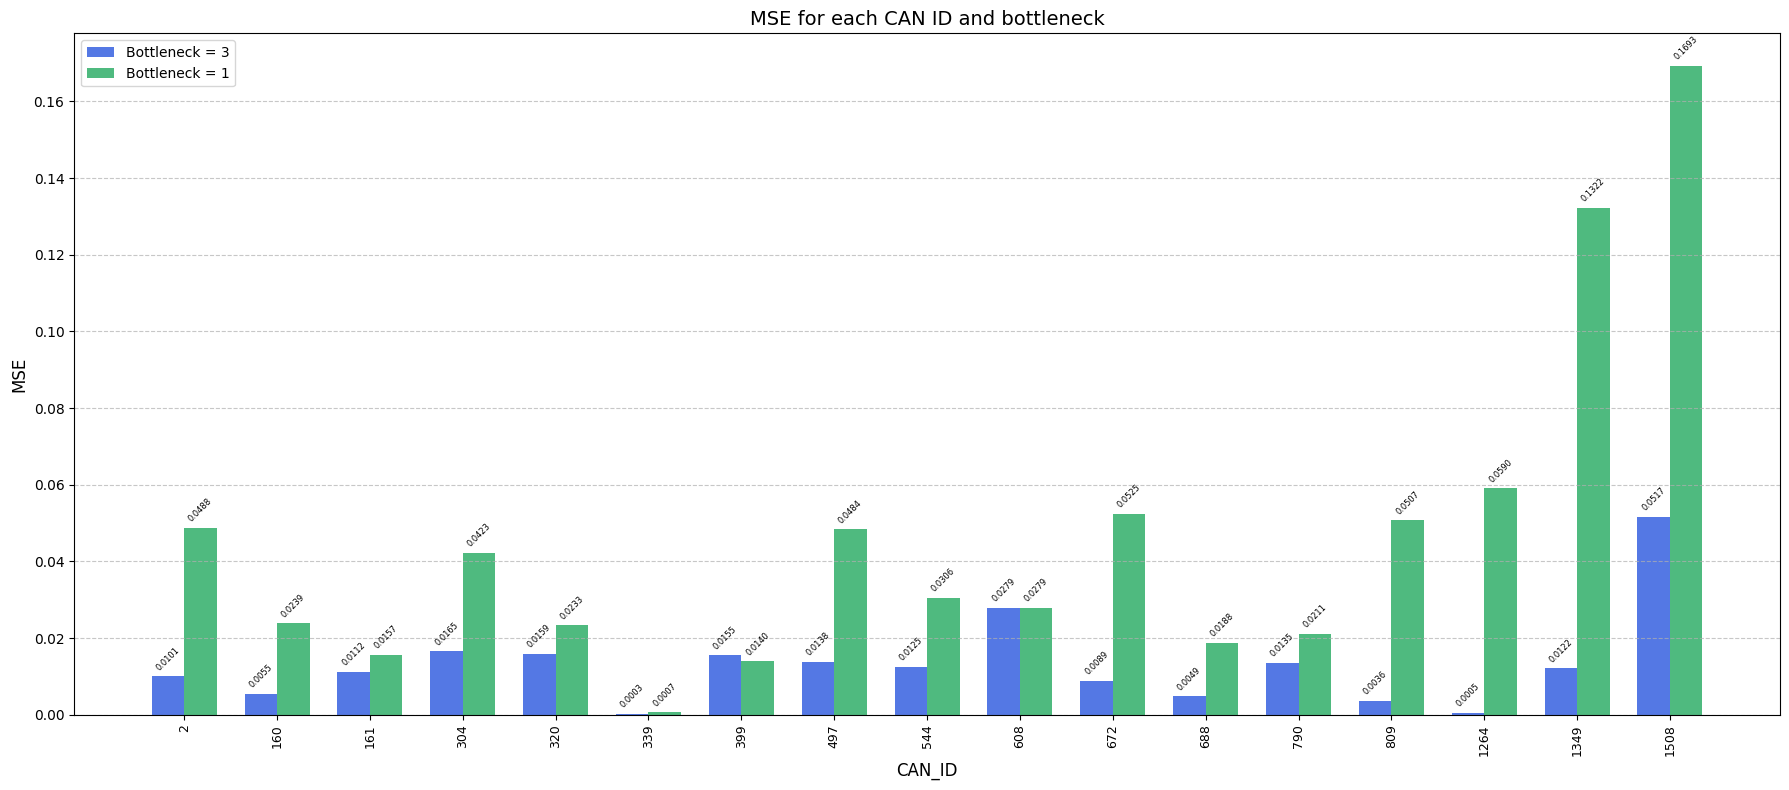

In [7]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

unique_ids = sorted(df['CAN_ID'].unique())
bottlenecks = [3, 1]

results = []
start_global = time.time()

for bottleneck_size in bottlenecks:
    print(f"--- PROFILING FOR BOTTLENECK: {bottleneck_size} ---")
    for i, can_id in enumerate(unique_ids):
        print(f"[{i+1}/{len(unique_ids)}] Processing CAN ID: {can_id} (Bottleneck: {bottleneck_size})...", end=" ")

        df_temp = df[df['CAN_ID'] == can_id].copy()
        df_temp = df_temp[df_temp['delta_t'] > 0.0]
        X_raw = df_temp.drop(columns=['Timestamp', 'CAN_ID']).fillna(0)

        if len(X_raw) < 1000:
            print(f"Skipped (too few frames: {len(X_raw)})")
            continue

        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X_raw)
        feature_count = X_scaled.shape[1]

        model_ae = create_autoencoder(feature_count, bottleneck_size)

        history = model_ae.fit(X_scaled, X_scaled, epochs=15, batch_size=2048, validation_split=0.1, verbose=0)
        final_mse = history.history['val_loss'][-1]

        results.append({
            'CAN_ID': str(can_id),
            'AE_Threshold_MSE': final_mse,
            'Bottleneck': bottleneck_size
        })

        print(f"Finished! (MSE: {final_mse:.4f})")

total_time = time.time() - start_global
print(f"\nFinished profiling {len(unique_ids)} modules for {len(bottlenecks)} bottlenecks in {total_time:.2f} seconds!")

df_results = pd.DataFrame(results)

df_pivot = df_results.pivot(index='CAN_ID', columns='Bottleneck', values='AE_Threshold_MSE').dropna()
df_pivot = df_pivot.sort_index(key=lambda x: pd.to_numeric(x))

fig, ax = plt.subplots(figsize=(18, 8))
n_groups = len(df_pivot.index)
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.9

rects1 = ax.bar(index - bar_width/2, df_pivot[3], bar_width,
                alpha=opacity,
                color='royalblue',
                label='Bottleneck = 3')

rects2 = ax.bar(index + bar_width/2, df_pivot[1], bar_width,
                alpha=opacity,
                color='mediumseagreen',
                label='Bottleneck = 1')

ax.set_xlabel('CAN_ID', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('MSE for each CAN ID and bottleneck', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(df_pivot.index, rotation=90, fontsize=9)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=6, rotation=45)

fig.tight_layout()
plt.savefig(CHARTS_DIR / 'MSE profiling bottleneck comparison.png')
plt.show()